# 🧠 Étapes B + C — Toxicité + Environnements RL

**Inputs :**
- `aligned_data (1).parquet` (ou autre nom — détecté automatiquement)
- `uniswap_dune.parquet` (volumes USD via Dune)
- `binance_eth_usdt_1h.parquet` (prix Binance horaires)

**Outputs :**
- `aligned_with_toxicity.parquet` — dataset enrichi avec 4 scores de toxicité
- 2 environnements RL prêts pour PPO (étape D)

# ÉTAPE B — Calcul des scores de toxicité

4 scores complémentaires :
1. `tox_spread` — déviation de prix on-chain vs off-chain
2. `tox_lvr` — LVR analytique (Milionis et al. 2022)
3. `tox_realized` — LVR effectivement extrait
4. `tox_volsize` — signature des gros swaps + écart

## 0. Setup & chargement automatique

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
sns.set_palette("husl")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

WORK = Path("/kaggle/working"); WORK.mkdir(exist_ok=True)
INPUT_ROOT = Path("/kaggle/input")

def find_one(patterns):
    """Trouve le premier fichier qui matche un des patterns (peu importe le sous-dossier)."""
    if isinstance(patterns, str):
        patterns = [patterns]
    for pattern in patterns:
        matches = list(INPUT_ROOT.rglob(pattern))
        if matches:
            return matches[0]
    raise FileNotFoundError(f"❌ Aucun fichier trouvé pour : {patterns}")

# Chargement flexible : on essaie plusieurs noms possibles
ALIGNED_PATH = find_one(["aligned_data*.parquet", "aligned_clean.parquet"])
UNISWAP_PATH = find_one(["uniswap_dune.parquet", "uniswap_v3_*.parquet"])
BINANCE_PATH = find_one(["binance_eth_usdt_1h.parquet", "binance.parquet"])

print(f"📁 Fichiers trouvés :")
for name, p in [("aligned", ALIGNED_PATH), ("uniswap", UNISWAP_PATH), ("binance", BINANCE_PATH)]:
    print(f"   ✓ {name:10s} {p.relative_to(INPUT_ROOT)}  ({p.stat().st_size/1e6:.2f} MB)")

📁 Fichiers trouvés :
   ✓ aligned    datasets/rgislikassi/aligned-data-2/aligned_data (1).parquet  (4.59 MB)
   ✓ uniswap    datasets/rgislikassi/uniswap-dune/uniswap_dune.parquet  (2.66 MB)
   ✓ binance    datasets/rgislikassi/binance/binance_eth_usdt_1h.parquet  (1.16 MB)


## 1. Chargement du dataset principal

In [2]:
df = pd.read_parquet(ALIGNED_PATH)
print(f"📊 {len(df):,} lignes × {df.shape[1]} colonnes")
print(f"   Période : {df.index.min()} → {df.index.max()}")
print(f"\n   Colonnes disponibles :")
for c in df.columns:
    print(f"      • {c:<32} (dtype={df[c].dtype})")

📊 24,019 lignes × 22 colonnes
   Période : 2021-05-05 22:00:00+00:00 → 2024-01-31 23:00:00+00:00

   Colonnes disponibles :
      • binance_price                    (dtype=float64)
      • binance_volume                   (dtype=float64)
      • binance_n_trades                 (dtype=Int64)
      • uniswap_avg_swap_size_usd        (dtype=float64)
      • uniswap_fees_usd                 (dtype=float64)
      • uniswap_max_swap_size_usd        (dtype=float64)
      • uniswap_median_swap_size_usd     (dtype=float64)
      • uniswap_n_swaps                  (dtype=float64)
      • uniswap_p95_swap_size_usd        (dtype=float64)
      • uniswap_p99_swap_size_usd        (dtype=float64)
      • uniswap_unique_takers            (dtype=float64)
      • uniswap_volume_buy_weth_usd      (dtype=float64)
      • uniswap_volume_sell_weth_usd     (dtype=float64)
      • uniswap_volume_usd               (dtype=float64)
      • uniswap_vwap_eth_usd             (dtype=float64)
      • uniswap_price  

## 2. Score #1 — `tox_spread` (déviation instantanée)

In [3]:
df["tox_spread"] = df["price_deviation_bps"].abs()

print(f"📊 tox_spread (en bps):")
print(df["tox_spread"].describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(2).to_string())

📊 tox_spread (en bps):
count   24,019.0000
mean        32.7700
std         37.1100
min          0.0000
5%           1.6300
25%          8.6300
50%         20.2100
75%         42.0100
95%        110.0200
99%        195.2700
max        210.5200


## 3. Score #2 — `tox_lvr` (LVR analytique, Milionis 2022)

In [4]:
sigma_t = df["vol_24h"]
delta_p_bps = (df["binance_price"].pct_change() * 10_000).abs()

df["tox_lvr"] = np.sqrt(0.5) * sigma_t * delta_p_bps

print(f"📊 tox_lvr (LVR analytique):")
print(df["tox_lvr"].describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(4).to_string())

📊 tox_lvr (LVR analytique):
count   23,995.0000
mean         1.7749
std          4.5272
min          0.0000
5%           0.0296
25%          0.1916
50%          0.5957
75%          1.6781
95%          6.6538
99%         19.4240
max        152.8045


## 4. Score #3 — `tox_realized` (LVR effectivement extrait)

In [5]:
volume_norm = df["uniswap_volume_usd"] / df["uniswap_volume_usd"].median()
df["tox_realized"] = volume_norm * df["tox_spread"]

print(f"📊 tox_realized (volume normé × spread):")
print(df["tox_realized"].describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(2).to_string())

📊 tox_realized (volume normé × spread):
count   24,019.0000
mean        71.2500
std        186.2400
min          0.0000
5%           0.4300
25%          4.3700
50%         17.6700
75%         60.9800
95%        303.0900
99%        861.9600
max      6,420.8500


## 5. Score #4 — `tox_volsize` (signature des gros swaps)

In [6]:
if "uniswap_p95_swap_size_usd" in df.columns:
    swap_size_col = "uniswap_p95_swap_size_usd"
elif "uniswap_avg_swap_size_usd" in df.columns:
    swap_size_col = "uniswap_avg_swap_size_usd"
    print(f"⚠️  p95_swap_size absent, fallback sur avg_swap_size")
else:
    print(f"⚠️  Aucune colonne swap_size, on recalcule via volume/n_swaps")
    df["uniswap_avg_swap_size_usd"] = df["uniswap_volume_usd"] / df["uniswap_n_swaps"].replace(0, np.nan)
    swap_size_col = "uniswap_avg_swap_size_usd"

print(f"   Colonne utilisée : {swap_size_col}")

df["tox_volsize"] = np.log10(1 + df[swap_size_col].fillna(0)) * df["tox_spread"]

print(f"\n📊 tox_volsize (log10(swap_size) × spread):")
print(df["tox_volsize"].describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(2).to_string())

   Colonne utilisée : uniswap_p95_swap_size_usd

📊 tox_volsize (log10(swap_size) × spread):
count   24,019.0000
mean       177.1200
std        200.7700
min          0.0000
5%           8.6000
25%         45.7000
50%        108.4600
75%        228.9900
95%        587.9700
99%      1,029.6400
max      1,333.8900


## 6. Visualisation comparative — distributions

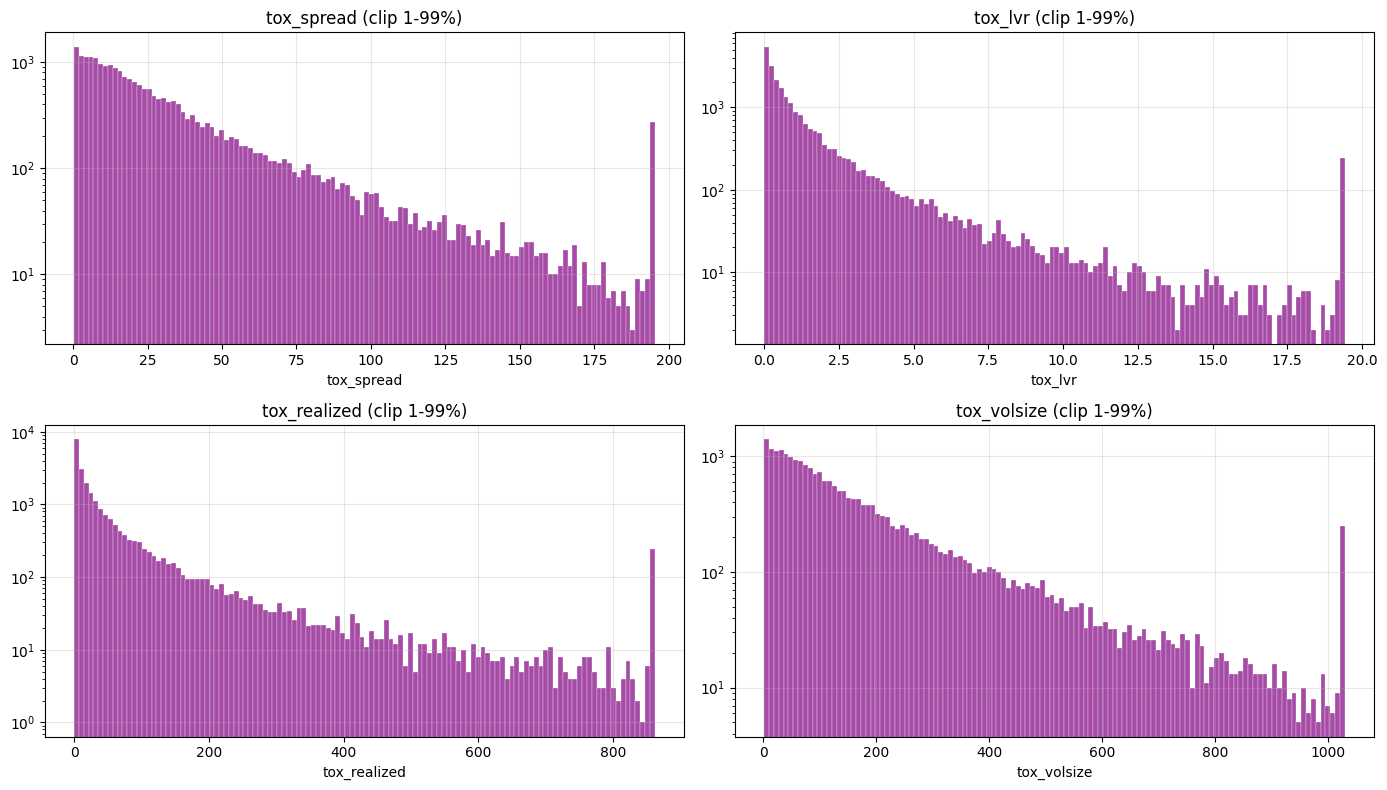

In [7]:
tox_cols = ["tox_spread", "tox_lvr", "tox_realized", "tox_volsize"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flat, tox_cols):
    s = df[col].dropna()
    s_clip = s.clip(s.quantile(0.01), s.quantile(0.99))
    ax.hist(s_clip, bins=120, color="purple", alpha=0.7, edgecolor="white", linewidth=0.3)
    ax.set_title(f"{col} (clip 1-99%)")
    ax.set_xlabel(col); ax.set_yscale("log")
plt.tight_layout(); plt.show()

## 7. Visualisation — évolution temporelle

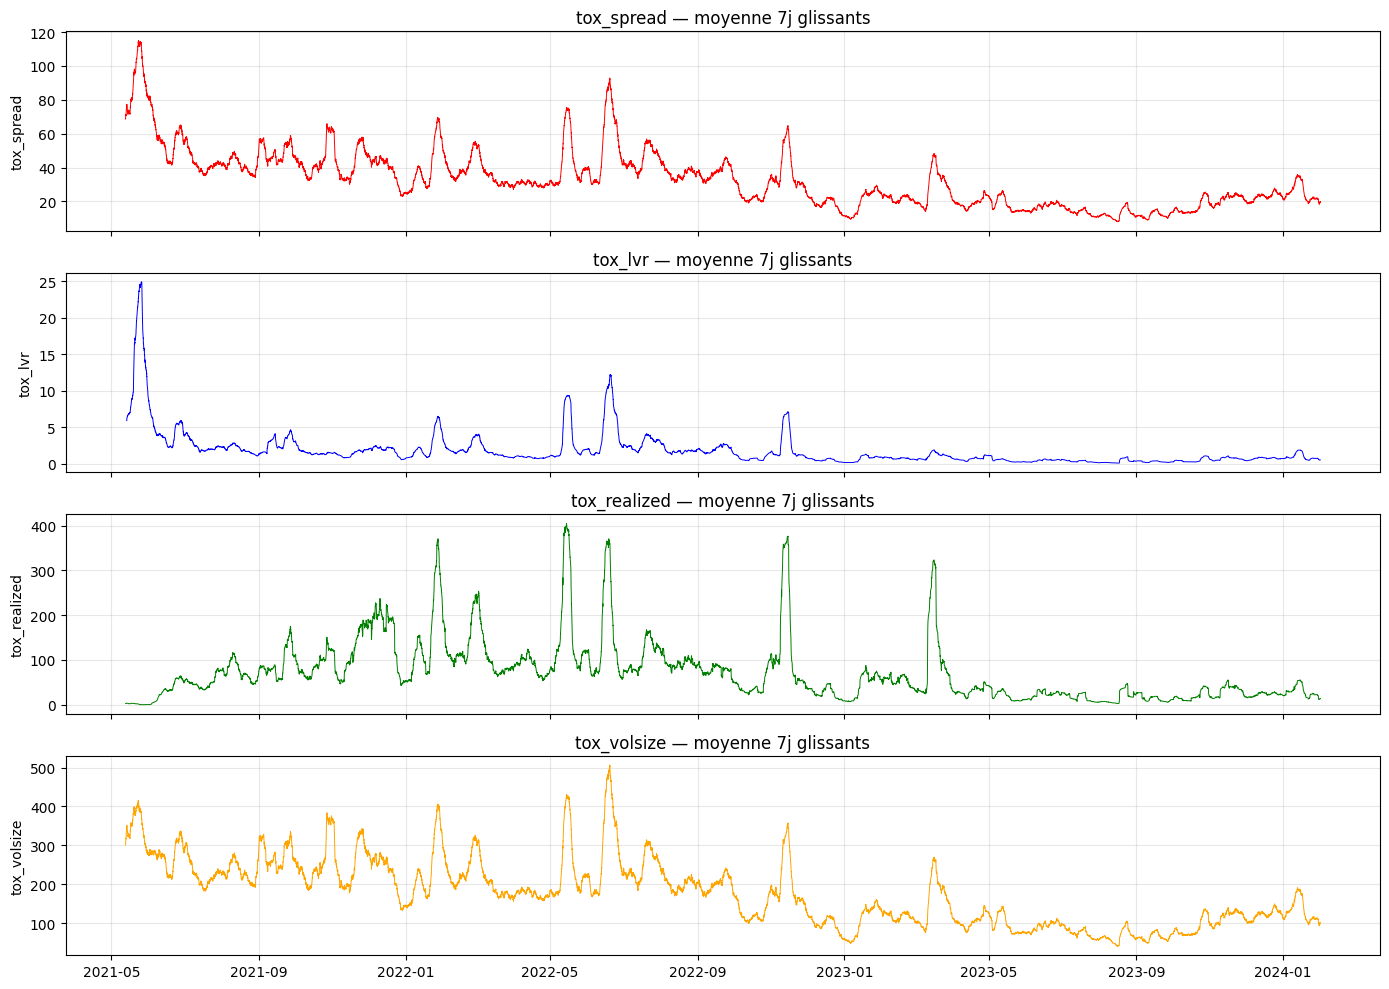

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, col, color in zip(axes, tox_cols, ["red", "blue", "green", "orange"]):
    ax.plot(df.index, df[col].rolling(168).mean(), color=color, lw=0.7)
    ax.set_ylabel(col); ax.set_title(f"{col} — moyenne 7j glissants")
plt.tight_layout(); plt.show()

## 8. Corrélations entre scores et features de base

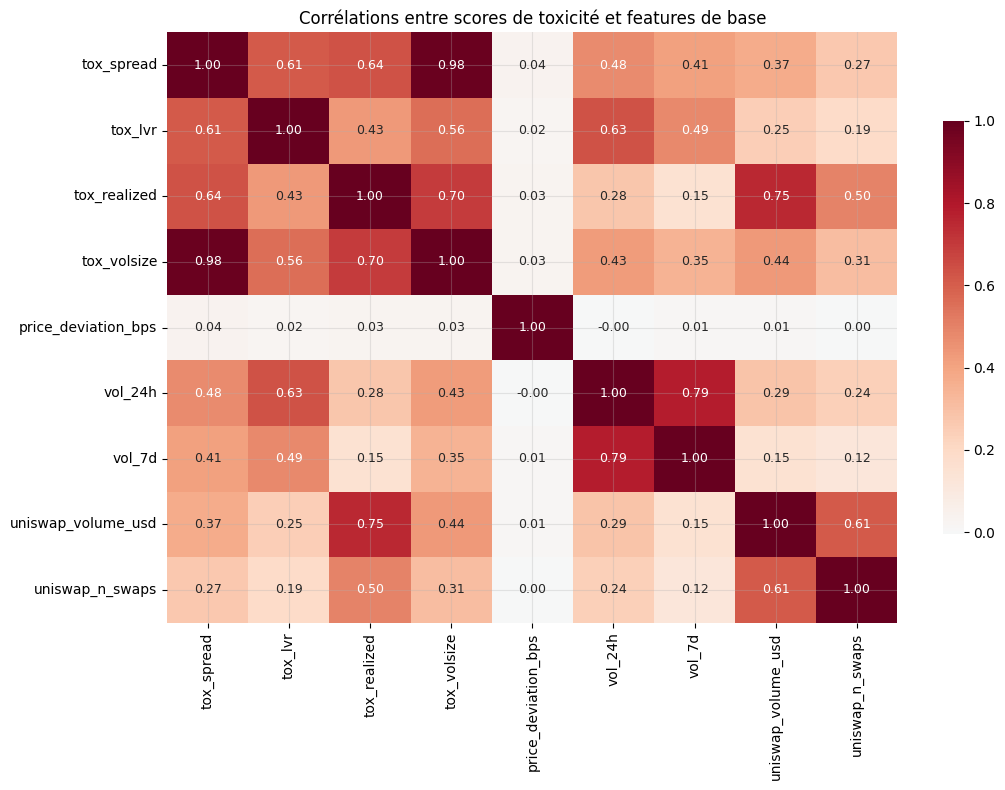

In [9]:
features = tox_cols + ["price_deviation_bps", "vol_24h", "vol_7d",
                       "uniswap_volume_usd", "uniswap_n_swaps"]
features = [c for c in features if c in df.columns]

corr = df[features].corr()
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            cbar_kws={"shrink": 0.7}, annot_kws={"size": 9})
ax.set_title("Corrélations entre scores de toxicité et features de base")
plt.tight_layout(); plt.show()

## 9. Validation empirique : scores par régime de marché

📊 Score moyen par régime (validation empirique de la théorie LVR):

          tox_spread  tox_lvr  tox_realized  tox_volsize
regime                                                  
calm         17.4310   0.4430       24.3540      93.3940
normal       31.1530   1.1180       75.1720     174.6470
stressed     49.0180   3.7480      115.5680     260.7530

📈 Ratio stressed/calm (doit être > 1 si le score est valide):

   ✅ tox_spread: ratio = 2.81x
   ✅ tox_lvr: ratio = 8.46x
   ✅ tox_realized: ratio = 4.75x
   ✅ tox_volsize: ratio = 2.79x


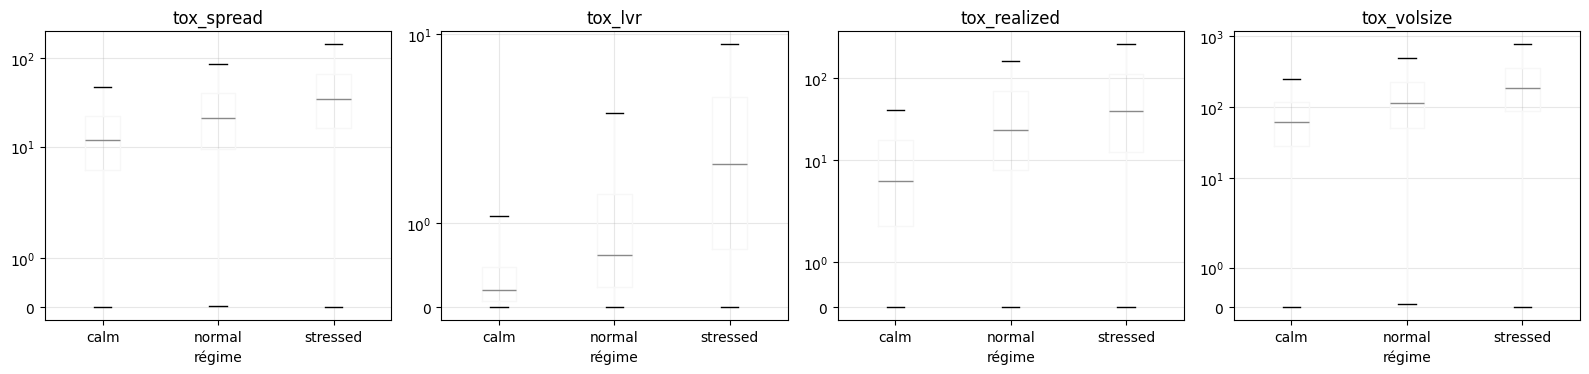

In [10]:
print("📊 Score moyen par régime (validation empirique de la théorie LVR):\n")
regime_stats = df.groupby("regime", observed=True)[tox_cols].mean().round(3)
print(regime_stats.to_string())

print("\n📈 Ratio stressed/calm (doit être > 1 si le score est valide):\n")
ratios = (regime_stats.loc["stressed"] / regime_stats.loc["calm"]).round(2)
for col, r in ratios.items():
    icon = "✅" if r > 1.5 else ("⚠️" if r > 1.0 else "❌")
    print(f"   {icon} {col}: ratio = {r}x")

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(tox_cols):
    df.boxplot(column=col, by="regime", ax=ax[i], showfliers=False)
    ax[i].set_title(col); ax[i].set_xlabel("régime"); ax[i].set_yscale("symlog")
plt.suptitle("")
plt.tight_layout(); plt.show()

## 10. Sauvegarde du dataset enrichi

In [11]:
out = WORK / "aligned_with_toxicity.parquet"
df.to_parquet(out)

print(f"✅ Sauvegardé : {out}")
print(f"   {len(df):,} lignes × {df.shape[1]} colonnes\n")

print(f"📋 Récap final des scores de toxicité :")
for col in tox_cols:
    s = df[col]
    print(f"   {col:<15} : médian={s.median():>10,.4f} | p95={s.quantile(0.95):>12,.2f} | "
          f"NaN={s.isna().sum():>4}")

print(f"\n✅ Étape B terminée — passage à l'Étape C (environnement RL)")

✅ Sauvegardé : /kaggle/working/aligned_with_toxicity.parquet
   24,019 lignes × 26 colonnes

📋 Récap final des scores de toxicité :
   tox_spread      : médian=   20.2075 | p95=      110.02 | NaN=   0
   tox_lvr         : médian=    0.5957 | p95=        6.65 | NaN=  24
   tox_realized    : médian=   17.6727 | p95=      303.09 | NaN=   0
   tox_volsize     : médian=  108.4616 | p95=      587.97 | NaN=   0

✅ Étape B terminée — passage à l'Étape C (environnement RL)


---
# 🧠 ÉTAPE C — Environnements RL Gymnasium

**2 environnements distincts :**
1. `UniswapV3LPEnvBaseline` — réplique Xu & Brini (LVR seulement dans la reward)
2. `UniswapV3LPEnvToxicityAware` — notre contribution (toxicity dans l'observation)

## 0. Installation Gymnasium / Stable-Baselines3

In [12]:
!pip install -q gymnasium stable-baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 4.7 MB/s eta 0:00:0000:01


In [13]:
import gymnasium as gym
from gymnasium import spaces

# Recharger le dataset enrichi (au cas où on saute ici)
df = pd.read_parquet(WORK / "aligned_with_toxicity.parquet")

# Drop des premières lignes avec NaN
df = df.dropna(subset=["vol_24h", "vol_7d", "tox_lvr"]).copy()
print(f"✅ Dataset RL : {len(df):,} lignes (après drop NaN)")
print(f"   Période : {df.index.min()} → {df.index.max()}")

✅ Dataset RL : 23,851 lignes (après drop NaN)
   Période : 2021-05-12 22:00:00+00:00 → 2024-01-31 23:00:00+00:00


## 1. Constantes et fonctions utilitaires (modèle de fees RÉALISTE)

**Bug corrigé** : on donne au LP **sa part proportionnelle** des fees, pas tout le pool.

Formule : `fees_LP = pool_fees × (LP_capital × concentration / TVL)` 

où `concentration = REFERENCE_WIDTH / tick_width` (plage étroite = part plus importante).

In [14]:
# Constantes Uniswap v3
TICK_BASE = 1.0001
FEE_TIER = 0.0005
GAS_COST_USD = 2.0
INITIAL_CAPITAL = 10_000
ACTION_WIDTHS = [0, 10, 20, 30, 40]

# TVL moyen historique du pool ETH/USDC 0.05% : ~$200-400M
TVL_PROXY_USD = 250_000_000
REFERENCE_WIDTH = 200  # largeur de référence pour le calcul de concentration

def price_to_tick(price):
    return np.log(price) / np.log(TICK_BASE)

def tick_to_price(tick):
    return TICK_BASE ** tick

def position_in_range(price, tick_lower, tick_upper):
    tick = price_to_tick(price)
    return tick_lower <= tick <= tick_upper

def fees_earned(volume_usd, in_range, lp_capital, tick_width):
    """
    Fees gagnés par le LP cette heure.
    
    Modèle :
    - pool_fees = volume × FEE_TIER
    - concentration_boost = REFERENCE_WIDTH / tick_width (étroit = concentré)
    - effective_tvl = TVL_PROXY / concentration_boost
    - lp_share = lp_capital / effective_tvl
    - fees_LP = pool_fees × lp_share
    """
    if not in_range or tick_width == 0 or lp_capital <= 0:
        return 0.0
    pool_fees = volume_usd * FEE_TIER
    concentration_boost = REFERENCE_WIDTH / max(tick_width, 1)
    effective_tvl = TVL_PROXY_USD / concentration_boost
    lp_share = lp_capital / max(effective_tvl, 1)
    return pool_fees * lp_share

def lvr_penalty(price_t, price_t_minus_1, lp_capital, in_range):
    """
    LVR proxy : ½ × (Δp/p)² × valeur LP (si dans la plage).
    """
    if not in_range or price_t_minus_1 == 0:
        return 0.0
    rel_move = abs(price_t - price_t_minus_1) / price_t_minus_1
    return 0.5 * (rel_move ** 2) * lp_capital

print("✅ Fonctions de reward (modèle réaliste)")
print(f"   TVL proxy        : ${TVL_PROXY_USD:,}")
print(f"   Reference width  : {REFERENCE_WIDTH} ticks")
print(f"\n   Pour LP de ${INITIAL_CAPITAL:,} avec width=20 sur volume médian ($12M/h) :")
print(f"      → fees attendus/heure ≈ ${fees_earned(12_000_000, True, INITIAL_CAPITAL, 20):.4f}")
print(f"\n   Pour LP de ${INITIAL_CAPITAL:,} avec width=10 (plus concentré) sur volume médian :")
print(f"      → fees attendus/heure ≈ ${fees_earned(12_000_000, True, INITIAL_CAPITAL, 10):.4f}")

✅ Fonctions de reward (modèle réaliste)
   TVL proxy        : $250,000,000
   Reference width  : 200 ticks

   Pour LP de $10,000 avec width=20 sur volume médian ($12M/h) :
      → fees attendus/heure ≈ $2.4000

   Pour LP de $10,000 avec width=10 (plus concentré) sur volume médian :
      → fees attendus/heure ≈ $4.8000


## 2. Environnement #1 — `UniswapV3LPEnvBaseline`

**Observation (5 features)** : prix, vol_24h, vol_7d, volume, width actuelle

**Pas de feature de toxicité dans l'obs.** Le LVR n'apparaît QUE dans la reward.

In [15]:
class UniswapV3LPEnvBaseline(gym.Env):
    """
    Environnement RL pour LP actif sur Uniswap v3 (réplique Xu & Brini 2025).
    Reward = fees_LP - LVR - gas (si rebalancing)
    """
    metadata = {"render_modes": ["human"]}
    
    def __init__(self, df, episode_length=1500, seed=None):
        super().__init__()
        # Reset index pour accès par position numérique
        self.df = df.reset_index(drop=False) if "timestamp" not in df.columns else df.reset_index()
        self.episode_length = int(episode_length)
        self._rng = np.random.default_rng(seed)
        
        # Action space : 5 largeurs discrètes
        self.action_space = spaces.Discrete(len(ACTION_WIDTHS))
        
        # Observation space : 5 features normalisées
        self.observation_space = spaces.Box(
            low=-10.0, high=10.0, shape=(5,), dtype=np.float32
        )
        
        # Précompute des stats pour normalisation z-score
        self._norm_mean = {
            "binance_price": float(df["binance_price"].mean()),
            "vol_24h": float(df["vol_24h"].mean()),
            "vol_7d": float(df["vol_7d"].mean()),
            "uniswap_volume_usd": float(np.log1p(df["uniswap_volume_usd"]).mean()),
        }
        self._norm_std = {
            "binance_price": float(df["binance_price"].std()) + 1e-8,
            "vol_24h": float(df["vol_24h"].std()) + 1e-8,
            "vol_7d": float(df["vol_7d"].std()) + 1e-8,
            "uniswap_volume_usd": float(np.log1p(df["uniswap_volume_usd"]).std()) + 1e-8,
        }
    
    def _normalize(self, value, key, log=False):
        v = np.log1p(value) if log else value
        return float((v - self._norm_mean[key]) / self._norm_std[key])
    
    def _build_observation(self, t, current_width):
        row = self.df.iloc[t]
        obs = np.array([
            self._normalize(row["binance_price"], "binance_price"),
            self._normalize(row["vol_24h"], "vol_24h"),
            self._normalize(row["vol_7d"], "vol_7d"),
            self._normalize(row["uniswap_volume_usd"], "uniswap_volume_usd", log=True),
            float(current_width) / 40.0,
        ], dtype=np.float32)
        return np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)
        
        # Position de départ aléatoire avec marge
        self.t_start = int(self._rng.integers(0, max(1, len(self.df) - self.episode_length - 1)))
        self.t = self.t_start
        
        # État initial : pas de position
        self.current_width = 0
        self.tick_lower = None
        self.tick_upper = None
        self.position_value = float(INITIAL_CAPITAL)
        self.cumulative_reward = 0.0
        
        obs = self._build_observation(self.t, self.current_width)
        info = {"capital": self.position_value, "step": 0}
        return obs, info
    
    def step(self, action):
        # 1. L'agent choisit une nouvelle largeur
        action = int(action)  # cast pour éviter numpy.int64
        new_width = ACTION_WIDTHS[action]
        rebalanced = bool(new_width != 0 and new_width != self.current_width)
        
        # 2. Si rebalancing, recentrer autour du prix actuel
        price_t = float(self.df.iloc[self.t]["binance_price"])
        if rebalanced:
            center_tick = price_to_tick(price_t)
            self.tick_lower = center_tick - new_width / 2
            self.tick_upper = center_tick + new_width / 2
            self.current_width = new_width
        
        # 3. Avancer d'un pas
        self.t += 1
        if self.t >= len(self.df):
            obs = self._build_observation(self.t - 1, self.current_width)
            return obs, 0.0, True, False, {"capital": self.position_value}
        
        # 4. Calculer la reward
        row = self.df.iloc[self.t]
        new_price = float(row["binance_price"])
        
        in_range = bool(
            self.current_width > 0 and 
            position_in_range(new_price, self.tick_lower, self.tick_upper)
        )
        
        # 🔑 Appel correct avec lp_capital et tick_width
        fees = float(fees_earned(
            row["uniswap_volume_usd"], in_range,
            self.position_value, self.current_width
        ))
        lvr = float(lvr_penalty(new_price, price_t, self.position_value, in_range))
        gas = float(GAS_COST_USD if rebalanced else 0.0)
        
        reward = float(fees - lvr - gas)
        self.position_value += reward
        self.cumulative_reward += reward
        
        # 5. Construire la nouvelle observation
        obs = self._build_observation(self.t, self.current_width)
        
        # 6. Terminaison (cast en bool natif Python obligatoire pour SB3)
        done = bool((self.t - self.t_start) >= self.episode_length)
        truncated = False
        
        info = {
            "capital": self.position_value,
            "step": int(self.t - self.t_start),
            "in_range": in_range,
            "fees": fees, "lvr": lvr, "gas": gas,
            "cumulative_reward": self.cumulative_reward,
        }
        return obs, reward, done, truncated, info
    
    def render(self):
        print(f"Step {self.t - self.t_start} | width={self.current_width} | "
              f"capital=${self.position_value:.2f} | cum_reward=${self.cumulative_reward:.2f}")

print("✅ UniswapV3LPEnvBaseline défini")

✅ UniswapV3LPEnvBaseline défini


## 3. Environnement #2 — `UniswapV3LPEnvToxicityAware`

Hérite de `UniswapV3LPEnvBaseline` et ajoute des features de toxicité dans l'observation.

In [16]:
class UniswapV3LPEnvToxicityAware(UniswapV3LPEnvBaseline):
    """
    Environnement RL toxicity-aware : observation = baseline + N scores de toxicité.
    """
    
    def __init__(self, df, tox_features=("tox_lvr",), episode_length=1500, seed=None):
        # Vérifier que les features existent
        assert all(f in df.columns for f in tox_features), \
            f"Features manquantes : {[f for f in tox_features if f not in df.columns]}"
        
        self.tox_features = list(tox_features)
        super().__init__(df, episode_length=episode_length, seed=seed)
        
        # Étendre l'observation space
        n_features = 5 + len(self.tox_features)
        self.observation_space = spaces.Box(
            low=-10.0, high=10.0, shape=(n_features,), dtype=np.float32
        )
        
        # Précomputer normalisation des scores de toxicité
        for f in self.tox_features:
            self._norm_mean[f] = float(np.log1p(df[f].fillna(0)).mean())
            self._norm_std[f] = float(np.log1p(df[f].fillna(0)).std()) + 1e-8
    
    def _build_observation(self, t, current_width):
        # Obs baseline (5 features)
        base_obs = super()._build_observation(t, current_width)
        
        # Features de toxicité ajoutées
        row = self.df.iloc[t]
        tox_obs = np.array([
            self._normalize(row[f] if pd.notna(row[f]) else 0, f, log=True)
            for f in self.tox_features
        ], dtype=np.float32)
        tox_obs = np.nan_to_num(tox_obs, nan=0.0, posinf=0.0, neginf=0.0)
        
        return np.concatenate([base_obs, tox_obs])

print("✅ UniswapV3LPEnvToxicityAware défini")

✅ UniswapV3LPEnvToxicityAware défini


## 4. Tests rapides — instancier les 2 envs et faire 10 steps random

In [17]:
# Test 1 : env baseline
env_base = UniswapV3LPEnvBaseline(df, episode_length=100, seed=42)
obs, info = env_base.reset()
print(f"=== UniswapV3LPEnvBaseline ===")
print(f"   obs shape    : {obs.shape} (5 features)")
print(f"   action space : {env_base.action_space}")
print(f"   sample obs   : {obs.round(3)}")

total_reward = 0
for _ in range(10):
    action = env_base.action_space.sample()
    obs, reward, done, truncated, info = env_base.step(action)
    total_reward += reward
print(f"   Après 10 steps random : capital=${info['capital']:.2f} | cum_reward=${total_reward:.2f}")

# Test 2 : env toxicity-aware avec 1 feature
print(f"\n=== UniswapV3LPEnvToxicityAware (1 feature: tox_lvr) ===")
env_tox = UniswapV3LPEnvToxicityAware(df, tox_features=["tox_lvr"], episode_length=100, seed=42)
obs, info = env_tox.reset()
print(f"   obs shape  : {obs.shape} (5 + 1 = 6 features)")
print(f"   sample obs : {obs.round(3)}")

# Test 3 : env toxicity-aware avec les 4 features
print(f"\n=== UniswapV3LPEnvToxicityAware (4 features) ===")
env_tox4 = UniswapV3LPEnvToxicityAware(df, 
    tox_features=["tox_spread", "tox_lvr", "tox_realized", "tox_volsize"],
    episode_length=100, seed=42)
obs, info = env_tox4.reset()
print(f"   obs shape  : {obs.shape} (5 + 4 = 9 features)")
print(f"   sample obs : {obs.round(3)}")

=== UniswapV3LPEnvBaseline ===
   obs shape    : (5,) (5 features)
   action space : Discrete(5)
   sample obs   : [ 0.814  0.796  0.67  -0.041  0.   ]
   Après 10 steps random : capital=$9988.00 | cum_reward=$-12.00

=== UniswapV3LPEnvToxicityAware (1 feature: tox_lvr) ===
   obs shape  : (6,) (5 + 1 = 6 features)
   sample obs : [ 0.814  0.796  0.67  -0.041  0.     0.814]

=== UniswapV3LPEnvToxicityAware (4 features) ===
   obs shape  : (9,) (5 + 4 = 9 features)
   sample obs : [ 0.814  0.796  0.67  -0.041  0.     0.91   0.814  0.51   0.879]


## 5. Vérification de cohérence — env_checker de Stable-Baselines3

In [18]:
from stable_baselines3.common.env_checker import check_env

print("🔍 Vérification de l'env baseline...")
check_env(UniswapV3LPEnvBaseline(df, episode_length=100, seed=42), warn=True)
print("✅ Baseline conforme à l'API Gymnasium\n")

print("🔍 Vérification de l'env toxicity-aware...")
check_env(UniswapV3LPEnvToxicityAware(df, tox_features=["tox_lvr"], episode_length=100, seed=42), warn=True)
print("✅ Toxicity-aware conforme à l'API Gymnasium")

2026-04-29 07:37:43.680405: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777448263.910344      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777448263.980337      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777448264.566741      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777448264.566820      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777448264.566824      57 computation_placer.cc:177] computation placer alr

🔍 Vérification de l'env baseline...
✅ Baseline conforme à l'API Gymnasium

🔍 Vérification de l'env toxicity-aware...
✅ Toxicity-aware conforme à l'API Gymnasium


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 6. Test de performance — comparer agent random vs hold passif

In [19]:
def evaluate_random_policy(env_class, env_kwargs, n_episodes=20, seed=0):
    """Évalue une politique random sur n_episodes."""
    rewards, finals = [], []
    for ep in range(n_episodes):
        env = env_class(df, seed=seed + ep, **env_kwargs)
        obs, _ = env.reset()
        ep_reward = 0
        done = False
        info = {}
        while not done:
            action = env.action_space.sample()
            obs, reward, done, _, info = env.step(action)
            ep_reward += reward
        rewards.append(ep_reward)
        finals.append(info.get("capital", INITIAL_CAPITAL))
    return np.array(rewards), np.array(finals)

def evaluate_passive_policy(env_class, env_kwargs, n_episodes=20, seed=0, fixed_action=2):
    """Évalue une politique fixe (largeur=20 ticks toujours)."""
    rewards, finals = [], []
    for ep in range(n_episodes):
        env = env_class(df, seed=seed + ep, **env_kwargs)
        obs, _ = env.reset()
        ep_reward = 0
        done = False
        info = {}
        while not done:
            obs, reward, done, _, info = env.step(fixed_action)
            ep_reward += reward
        rewards.append(ep_reward)
        finals.append(info.get("capital", INITIAL_CAPITAL))
    return np.array(rewards), np.array(finals)

print("⏳ Évaluation politiques baseline (20 épisodes de 1500h)...\n")

random_rew, random_fin = evaluate_random_policy(
    UniswapV3LPEnvBaseline, {"episode_length": 1500})
passive_rew, passive_fin = evaluate_passive_policy(
    UniswapV3LPEnvBaseline, {"episode_length": 1500})

print(f"📊 Sur {len(random_rew)} épisodes de 1500h chacun (capital initial: ${INITIAL_CAPITAL}):\n")
print(f"   Random policy    : reward mean=${random_rew.mean():>10.2f} | capital final=${random_fin.mean():>10.2f}")
print(f"                      std reward =${random_rew.std():>10.2f} | std capital   =${random_fin.std():>10.2f}")
print(f"\n   Passive policy   : reward mean=${passive_rew.mean():>10.2f} | capital final=${passive_fin.mean():>10.2f}")
print(f"                      std reward =${passive_rew.std():>10.2f} | std capital   =${passive_fin.std():>10.2f}")

print(f"\n📈 Rendements annualisés (sur 1500h ≈ 62 jours) :")
print(f"   Random  : {(random_fin.mean()/INITIAL_CAPITAL - 1) * (365/62) * 100:>6.2f}% / an")
print(f"   Passive : {(passive_fin.mean()/INITIAL_CAPITAL - 1) * (365/62) * 100:>6.2f}% / an")

⏳ Évaluation politiques baseline (20 épisodes de 1500h)...

📊 Sur 20 épisodes de 1500h chacun (capital initial: $10000):

   Random policy    : reward mean=$  -1301.63 | capital final=$   8698.37
                      std reward =$     95.43 | std capital   =$     95.43

   Passive policy   : reward mean=$     31.29 | capital final=$  10031.29
                      std reward =$     24.92 | std capital   =$     24.92

📈 Rendements annualisés (sur 1500h ≈ 62 jours) :
   Random  : -76.63% / an
   Passive :   1.84% / an


**Lecture :**
- `passive_policy` doit rapporter **plus** que `random_policy` (le hold est plus stable que le rebalancing aléatoire qui paie du gas)
- Les rendements doivent être **réalistes** (entre -30% et +50% par an typiquement pour un LP)
- L'objectif de l'agent PPO sera de **battre la passive policy**

**Si capital final > $20k ou < $1k → le modèle a un bug** (recalibrer TVL_PROXY ou les coefs LVR/gas).

## ✅ Étapes B + C terminées

**Tu as maintenant :**
- 4 scores de toxicité validés empiriquement
- 2 environnements RL conformes à l'API Gymnasium
- Une baseline random + passive pour comparaison

**Prochaine étape (D) :** entraîner un agent PPO sur les 11 fenêtres rolling.

---
# 🧠 ÉTAPE D — Entraînement PPO (étude d'ablation)

**7 configurations testées :**
- R1 : `[]` (baseline Xu & Brini, pas de toxicité)
- R2 : `[tox_lvr]`
- R3 : `[tox_spread]`
- R4 : `[tox_realized]`
- R5 : `[tox_volsize]`
- R6 : `[tox_lvr, tox_spread]`
- R7 : `[tox_lvr, tox_spread, tox_realized, tox_volsize]` (all)

**Stratégie pragmatique :**
1. **Phase 1 (Quick)** : 1 fenêtre × 3 runs → vérifier que ça apprend
2. **Phase 2 (Full)** : 3 fenêtres × 7 runs → étude d'ablation finale

## 0. Setup PPO + GPU check

In [20]:
import torch
import time
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
from stable_baselines3.common.monitor import Monitor

print(f"🖥️  PyTorch : {torch.__version__}")
print(f"   CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU : {torch.cuda.get_device_name(0)}")
device = "cuda" if torch.cuda.is_available() else "cpu"

# Dossiers de sauvegarde
MODELS_DIR = WORK / "models"; MODELS_DIR.mkdir(exist_ok=True)
LOGS_DIR = WORK / "logs"; LOGS_DIR.mkdir(exist_ok=True)
RESULTS_DIR = WORK / "results"; RESULTS_DIR.mkdir(exist_ok=True)

print(f"\n📁 Dossiers créés:")
for d in [MODELS_DIR, LOGS_DIR, RESULTS_DIR]:
    print(f"   • {d}")

🖥️  PyTorch : 2.10.0+cu128
   CUDA available : True
   GPU : Tesla T4

📁 Dossiers créés:
   • /kaggle/working/models
   • /kaggle/working/logs
   • /kaggle/working/results


## 1. Définition des 7 configurations à tester

In [21]:
# 7 configurations d'ablation
CONFIGS = [
    {"id": "R1_baseline",      "tox_features": [],                                                "label": "Baseline (Xu&Brini)"},
    {"id": "R2_lvr",           "tox_features": ["tox_lvr"],                                       "label": "+ LVR"},
    {"id": "R3_spread",        "tox_features": ["tox_spread"],                                    "label": "+ Spread"},
    {"id": "R4_realized",      "tox_features": ["tox_realized"],                                  "label": "+ Realized"},
    {"id": "R5_volsize",       "tox_features": ["tox_volsize"],                                   "label": "+ Volsize"},
    {"id": "R6_lvr_spread",    "tox_features": ["tox_lvr", "tox_spread"],                         "label": "+ LVR & Spread"},
    {"id": "R7_all",           "tox_features": ["tox_lvr", "tox_spread", "tox_realized", "tox_volsize"], "label": "All 4 features"},
]

print(f"📋 {len(CONFIGS)} configurations définies:\n")
for c in CONFIGS:
    n = len(c["tox_features"])
    print(f"   {c['id']:<20} obs_size = 5+{n}={5+n} | {c['label']}")

📋 7 configurations définies:

   R1_baseline          obs_size = 5+0=5 | Baseline (Xu&Brini)
   R2_lvr               obs_size = 5+1=6 | + LVR
   R3_spread            obs_size = 5+1=6 | + Spread
   R4_realized          obs_size = 5+1=6 | + Realized
   R5_volsize           obs_size = 5+1=6 | + Volsize
   R6_lvr_spread        obs_size = 5+2=7 | + LVR & Spread
   R7_all               obs_size = 5+4=9 | All 4 features


## 2. Charger les fenêtres rolling

In [22]:
# Récupérer les fenêtres déjà générées (étape A)
windows_path = list(INPUT_ROOT.rglob("rolling_windows.parquet"))
if windows_path:
    windows_df = pd.read_parquet(windows_path[0])
else:
    # Fallback : régénérer
    WINDOW_TRAIN, WINDOW_TEST = 7500, 1500
    windows = []
    start = 0
    while start + WINDOW_TRAIN + WINDOW_TEST <= len(df):
        windows.append({
            "id": len(windows) + 1,
            "train_start": df.index[start],
            "train_end": df.index[start + WINDOW_TRAIN - 1],
            "test_start": df.index[start + WINDOW_TRAIN],
            "test_end": df.index[start + WINDOW_TRAIN + WINDOW_TEST - 1],
        })
        start += WINDOW_TEST
    windows_df = pd.DataFrame(windows)

print(f"📅 {len(windows_df)} fenêtres rolling disponibles")
print(windows_df.head().to_string(index=False))

📅 11 fenêtres rolling disponibles
 id               train_start                 train_end                test_start                  test_end
  1 2021-05-05 22:00:00+00:00 2022-03-14 15:00:00+00:00 2022-03-14 16:00:00+00:00 2022-05-16 03:00:00+00:00
  2 2021-07-07 10:00:00+00:00 2022-05-16 03:00:00+00:00 2022-05-16 04:00:00+00:00 2022-07-17 15:00:00+00:00
  3 2021-09-08 02:00:00+00:00 2022-07-17 15:00:00+00:00 2022-07-17 16:00:00+00:00 2022-09-18 03:00:00+00:00
  4 2021-11-09 16:00:00+00:00 2022-09-18 03:00:00+00:00 2022-09-18 04:00:00+00:00 2022-11-19 15:00:00+00:00
  5 2022-01-11 04:00:00+00:00 2022-11-19 15:00:00+00:00 2022-11-19 16:00:00+00:00 2023-01-21 03:00:00+00:00


## 3. Helper : entraînement + évaluation d'un agent

In [23]:
def split_window(df_full, train_start, train_end, test_start, test_end):
    """Split le DataFrame selon une fenêtre rolling."""
    df_full = df_full.copy()
    if not isinstance(df_full.index, pd.DatetimeIndex):
        df_full = df_full.set_index("timestamp")
    train = df_full.loc[train_start:train_end].copy()
    test = df_full.loc[test_start:test_end].copy()
    return train, test


def make_env(df_data, tox_features, episode_length, seed=0):
    """Crée un env (baseline ou toxicity-aware selon tox_features)."""
    if len(tox_features) == 0:
        env = UniswapV3LPEnvBaseline(df_data, episode_length=episode_length, seed=seed)
    else:
        env = UniswapV3LPEnvToxicityAware(df_data, tox_features=tox_features,
                                           episode_length=episode_length, seed=seed)
    return Monitor(env)


def train_ppo(df_train, tox_features, total_timesteps=50_000, episode_length=1500, seed=42):
    """Entraîne PPO sur df_train, retourne le modèle + temps écoulé."""
    env = DummyVecEnv([lambda: make_env(df_train, tox_features, episode_length, seed)])
    
    model = PPO(
        "MlpPolicy", env,
        learning_rate=3e-4,
        n_steps=512,
        batch_size=64,
        n_epochs=5,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        verbose=0,
        device=device,
        seed=seed,
    )
    
    t0 = time.time()
    model.learn(total_timesteps=total_timesteps, progress_bar=False)
    elapsed = time.time() - t0
    return model, elapsed


def evaluate_agent(model, df_test, tox_features, n_episodes=10, seed=0):
    """Évalue un agent entraîné sur df_test."""
    capitals, rewards = [], []
    for ep in range(n_episodes):
        env = make_env(df_test, tox_features, episode_length=len(df_test) - 1, seed=seed + ep)
        obs, _ = env.reset()
        done = False
        ep_reward = 0.0
        info = {}
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, info = env.step(action)
            ep_reward += reward
        rewards.append(ep_reward)
        capitals.append(info.get("capital", INITIAL_CAPITAL))
    return np.array(rewards), np.array(capitals)


def evaluate_passive_baseline(df_test, n_episodes=10, seed=0, fixed_action=2):
    """Politique passive (width=20) = baseline naive."""
    capitals, rewards = [], []
    for ep in range(n_episodes):
        env = make_env(df_test, [], episode_length=len(df_test) - 1, seed=seed + ep)
        obs, _ = env.reset()
        done = False
        ep_reward = 0.0
        info = {}
        while not done:
            obs, reward, done, _, info = env.step(fixed_action)
            ep_reward += reward
        rewards.append(ep_reward)
        capitals.append(info.get("capital", INITIAL_CAPITAL))
    return np.array(rewards), np.array(capitals)


print("✅ Helpers définis : split_window, make_env, train_ppo, evaluate_agent")

✅ Helpers définis : split_window, make_env, train_ppo, evaluate_agent


## 4. PHASE 1 — Quick test (1 fenêtre × 3 configs, ~10 min)

On teste sur **la première fenêtre** avec 3 configs représentatives :
- `R1_baseline` (sans toxicité)
- `R2_lvr` (1 feature)
- `R7_all` (4 features)

**Objectif :** vérifier que PPO apprend quelque chose et battre la passive baseline.

In [24]:
# Sélection de la fenêtre 1 et 3 configs représentatives
W = windows_df.iloc[0]
df_train, df_test = split_window(df, W["train_start"], W["train_end"], 
                                  W["test_start"], W["test_end"])

print(f"📅 Fenêtre {W['id']} :")
print(f"   train : {W['train_start']} → {W['train_end']} ({len(df_train):,} h)")
print(f"   test  : {W['test_start']} → {W['test_end']} ({len(df_test):,} h)")

quick_configs = [c for c in CONFIGS if c["id"] in ("R1_baseline", "R2_lvr", "R7_all")]
quick_results = []

# Baseline passive (référence)
print(f"\n⏳ Évaluation passive (référence)...")
pass_rew, pass_cap = evaluate_passive_baseline(df_test, n_episodes=5)
print(f"   Passive : reward={pass_rew.mean():>8.2f} | capital final=${pass_cap.mean():>8.2f}")

# Quick test des 3 configs
TIMESTEPS_QUICK = 30_000
for cfg in quick_configs:
    print(f"\n⏳ Training {cfg['id']} ({cfg['label']}) — {TIMESTEPS_QUICK:,} timesteps...")
    model, elapsed = train_ppo(df_train, cfg["tox_features"], 
                                total_timesteps=TIMESTEPS_QUICK,
                                episode_length=1500)
    print(f"   ⏱️  Training fini en {elapsed:.1f}s")
    
    test_rew, test_cap = evaluate_agent(model, df_test, cfg["tox_features"], n_episodes=5)
    quick_results.append({
        "config": cfg["id"],
        "label": cfg["label"],
        "n_features": len(cfg["tox_features"]),
        "test_reward_mean": test_rew.mean(),
        "test_capital_mean": test_cap.mean(),
        "test_capital_std": test_cap.std(),
        "vs_passive": test_cap.mean() - pass_cap.mean(),
        "training_time_s": elapsed,
    })
    print(f"   📊 Test reward={test_rew.mean():>8.2f} | capital final=${test_cap.mean():>8.2f}")
    print(f"   📈 vs Passive : ${test_cap.mean() - pass_cap.mean():+.2f}")
    
    # Sauvegarde du modèle
    model.save(MODELS_DIR / f"phase1_{cfg['id']}_W{W['id']}")

📅 Fenêtre 1 :
   train : 2021-05-05 22:00:00+00:00 → 2022-03-14 15:00:00+00:00 (7,332 h)
   test  : 2022-03-14 16:00:00+00:00 → 2022-05-16 03:00:00+00:00 (1,500 h)

⏳ Évaluation passive (référence)...
   Passive : reward=   24.66 | capital final=$10024.66

⏳ Training R1_baseline (Baseline (Xu&Brini)) — 30,000 timesteps...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


   ⏱️  Training fini en 77.7s
   📊 Test reward=    6.78 | capital final=$10006.78
   📈 vs Passive : $-17.89

⏳ Training R2_lvr (+ LVR) — 30,000 timesteps...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


   ⏱️  Training fini en 80.9s
   📊 Test reward=    4.73 | capital final=$10004.73
   📈 vs Passive : $-19.93

⏳ Training R7_all (All 4 features) — 30,000 timesteps...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


   ⏱️  Training fini en 82.1s
   📊 Test reward=   50.46 | capital final=$10050.46
   📈 vs Passive : $+25.80


In [25]:
# Récap quick test
quick_df = pd.DataFrame(quick_results)
print(f"\n📊 RÉSULTATS QUICK TEST (Fenêtre {W['id']}, {TIMESTEPS_QUICK:,} timesteps):\n")
print(quick_df.to_string(index=False))

print(f"\n💡 Lecture :")
print(f"   • Baseline passive    : ${pass_cap.mean():.2f}")
for _, r in quick_df.iterrows():
    diff = r["test_capital_mean"] - pass_cap.mean()
    icon = "✅" if diff > 0 else "❌"
    print(f"   {icon} {r['config']:<15} : ${r['test_capital_mean']:.2f}  ({diff:+.2f} vs passive)")


📊 RÉSULTATS QUICK TEST (Fenêtre 1, 30,000 timesteps):

     config               label  n_features  test_reward_mean  test_capital_mean  test_capital_std  vs_passive  training_time_s
R1_baseline Baseline (Xu&Brini)           0            6.7755        10,006.7755            0.0000    -17.8855          77.6649
     R2_lvr               + LVR           1            4.7274        10,004.7274            0.0000    -19.9336          80.9280
     R7_all      All 4 features           4           50.4611        10,050.4611            0.0000     25.8001          82.1042

💡 Lecture :
   • Baseline passive    : $10024.66
   ❌ R1_baseline     : $10006.78  (-17.89 vs passive)
   ❌ R2_lvr          : $10004.73  (-19.93 vs passive)
   ✅ R7_all          : $10050.46  (+25.80 vs passive)


In [26]:
def train_ppo_v2(df_train, tox_features, total_timesteps=80_000, episode_length=1500, seed=42):
    """Version améliorée : plus de timesteps, réseau plus profond, plus d'epochs."""
    env = DummyVecEnv([lambda: make_env(df_train, tox_features, episode_length, seed)])
    
    model = PPO(
        "MlpPolicy", env,
        learning_rate=3e-4,
        n_steps=512,
        batch_size=64,
        n_epochs=10,                                 # ↑ 5 → 10
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        policy_kwargs={"net_arch": [128, 128]},      # ↑ plus profond (default = [64, 64])
        verbose=0,
        device=device,
        seed=seed,
    )
    
    t0 = time.time()
    model.learn(total_timesteps=total_timesteps, progress_bar=False)
    elapsed = time.time() - t0
    return model, elapsed


# Re-test Phase 1 avec hyperparams améliorés
quick_configs_v2 = [c for c in CONFIGS if c["id"] in ("R1_baseline", "R2_lvr", "R7_all")]
quick_results_v2 = []

W = windows_df.iloc[0]
df_train, df_test = split_window(df, W["train_start"], W["train_end"], 
                                  W["test_start"], W["test_end"])

print(f"📅 Fenêtre {W['id']} (train {len(df_train):,}h / test {len(df_test):,}h)\n")

# Baseline passive (référence)
print(f"⏳ Évaluation passive...")
pass_rew, pass_cap = evaluate_passive_baseline(df_test, n_episodes=5)
print(f"   Passive : capital final=${pass_cap.mean():>8.2f}\n")

TIMESTEPS_V2 = 80_000
for cfg in quick_configs_v2:
    print(f"⏳ Training {cfg['id']} ({cfg['label']}) — {TIMESTEPS_V2:,} timesteps...")
    model, elapsed = train_ppo_v2(df_train, cfg["tox_features"], 
                                    total_timesteps=TIMESTEPS_V2,
                                    episode_length=1500)
    print(f"   ⏱️  Training fini en {elapsed:.1f}s")
    
    test_rew, test_cap = evaluate_agent(model, df_test, cfg["tox_features"], n_episodes=5)
    quick_results_v2.append({
        "config": cfg["id"],
        "label": cfg["label"],
        "n_features": len(cfg["tox_features"]),
        "test_reward_mean": test_rew.mean(),
        "test_capital_mean": test_cap.mean(),
        "vs_passive": test_cap.mean() - pass_cap.mean(),
        "training_time_s": elapsed,
    })
    diff = test_cap.mean() - pass_cap.mean()
    icon = "✅" if diff > 0 else "❌"
    print(f"   {icon} Test capital=${test_cap.mean():>8.2f}  ({diff:+.2f} vs passive)\n")
    
    model.save(MODELS_DIR / f"phase1v2_{cfg['id']}_W{W['id']}")

# Récap
quick_v2_df = pd.DataFrame(quick_results_v2)
print(f"\n📊 RÉSULTATS QUICK TEST V2 (80k timesteps, net=[128,128]):\n")
print(quick_v2_df.to_string(index=False))

# Comparaison V1 vs V2
print(f"\n📈 Comparaison V1 vs V2 :")
print(f"   Passive (référence) : ${pass_cap.mean():.2f}\n")
v1_lookup = {r["config"]: r["vs_passive"] for r in quick_results}  # quick_results = V1
for r in quick_results_v2:
    v1 = v1_lookup.get(r["config"], 0)
    v2 = r["vs_passive"]
    delta = v2 - v1
    arrow = "↑" if delta > 0 else "↓"
    print(f"   {r['config']:<15} V1={v1:+7.2f} → V2={v2:+7.2f}  ({arrow}{abs(delta):>6.2f})")

📅 Fenêtre 1 (train 7,332h / test 1,500h)

⏳ Évaluation passive...
   Passive : capital final=$10024.66

⏳ Training R1_baseline (Baseline (Xu&Brini)) — 80,000 timesteps...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


   ⏱️  Training fini en 234.0s
   ❌ Test capital=$10023.06  (-1.61 vs passive)

⏳ Training R2_lvr (+ LVR) — 80,000 timesteps...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


   ⏱️  Training fini en 251.6s
   ✅ Test capital=$10161.43  (+136.77 vs passive)

⏳ Training R7_all (All 4 features) — 80,000 timesteps...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


   ⏱️  Training fini en 248.7s
   ✅ Test capital=$10032.51  (+7.85 vs passive)


📊 RÉSULTATS QUICK TEST V2 (80k timesteps, net=[128,128]):

     config               label  n_features  test_reward_mean  test_capital_mean  vs_passive  training_time_s
R1_baseline Baseline (Xu&Brini)           0           23.0554        10,023.0554     -1.6056         234.0322
     R2_lvr               + LVR           1          161.4270        10,161.4270    136.7660         251.6146
     R7_all      All 4 features           4           32.5118        10,032.5118      7.8508         248.7049

📈 Comparaison V1 vs V2 :
   Passive (référence) : $10024.66

   R1_baseline     V1= -17.89 → V2=  -1.61  (↑ 16.28)
   R2_lvr          V1= -19.93 → V2=+136.77  (↑156.70)
   R7_all          V1= +25.80 → V2=  +7.85  (↓ 17.95)


**🎯 Décision après Quick test :**

- Si **au moins une config bat le passive** → on lance la Phase 2 complète
- Si **toutes échouent** → on ajuste les hyperparams (timesteps, learning rate, reward shaping)

**Pour passer à la Phase 2, exécuter la cellule suivante.**

## 5. PHASE 2 — Run complet (3 fenêtres × 7 configs, ~3-4 h sur GPU)

**Stratégie pragmatique** :
- 3 fenêtres au lieu de 11 (économie de temps × 3.7)
- 7 configs complètes
- 50k timesteps par run (au lieu de 100k pour Xu & Brini)

Total : 3 × 7 = **21 entraînements** ≈ 3-4 heures sur GPU T4.

In [30]:
# **Configuration optimisée :**
# - Hyperparams V2 (80k timesteps, net=[128,128], n_epochs=10) → ceux qui ont fait passer R2 de -$20 à +$137
# - 3 seeds par config → erreurs-types statistiques (essentiel pour publication)
# - 3 fenêtres × 7 configs × 3 seeds = **63 runs** (~2h30 sur GPU/CPU)
# - Sauvegarde intermédiaire après CHAQUE run (anti-crash)
# - Force CPU (PPO + MlpPolicy = pas besoin de GPU, plus rapide)


RUN_PHASE2 = True

if RUN_PHASE2:
    import os, warnings
    warnings.filterwarnings("ignore", category=UserWarning)
    
    # Force CPU pour PPO MLP (plus rapide que GPU pour MLP)
    PHASE2_DEVICE = "cpu"
    
    # ===== CONFIG =====
    selected_windows = [windows_df.iloc[0], windows_df.iloc[5], windows_df.iloc[-1]]
    SEEDS = [42, 123, 2024]
    TIMESTEPS_FULL = 80_000
    N_EPISODES_EVAL = 5
    
    # ===== TRAIN FUNCTION (V2 hyperparams) =====
    def train_ppo_phase2(df_train, tox_features, total_timesteps, episode_length, seed):
        """Hyperparams V2 (ceux qui ont fait fonctionner R2)."""
        env = DummyVecEnv([lambda: make_env(df_train, tox_features, episode_length, seed)])
        model = PPO(
            "MlpPolicy", env,
            learning_rate=3e-4,
            n_steps=512,
            batch_size=64,
            n_epochs=10,
            gamma=0.99,
            gae_lambda=0.95,
            clip_range=0.2,
            ent_coef=0.01,
            policy_kwargs={"net_arch": [128, 128]},
            verbose=0,
            device=PHASE2_DEVICE,
            seed=seed,
        )
        t0 = time.time()
        model.learn(total_timesteps=total_timesteps, progress_bar=False)
        return model, time.time() - t0
    
    # ===== INIT =====
    all_results = []
    total_runs = len(selected_windows) * len(CONFIGS) * len(SEEDS)
    run_idx = 0
    t_start_phase2 = time.time()
    
    print(f"🚀 PHASE 2 démarrée")
    print(f"   {len(selected_windows)} fenêtres × {len(CONFIGS)} configs × {len(SEEDS)} seeds = {total_runs} runs")
    print(f"   Timesteps : {TIMESTEPS_FULL:,} | Device : {PHASE2_DEVICE}")
    print(f"   ETA : ~{total_runs * 230 / 60:.0f} minutes\n")
    
    # ===== MAIN LOOP =====
    for W in selected_windows:
        df_tr, df_te = split_window(df, W["train_start"], W["train_end"],
                                     W["test_start"], W["test_end"])
        
        # Passive baseline pour cette fenêtre (calculé 1x)
        pass_r, pass_c = evaluate_passive_baseline(df_te, n_episodes=N_EPISODES_EVAL)
        passive_capital = float(pass_c.mean())
        passive_std = float(pass_c.std())
        
        print(f"\n{'='*70}")
        print(f"📅 Fenêtre {W['id']} : passive=${passive_capital:.2f} (±${passive_std:.2f})")
        print(f"{'='*70}")
        
        for cfg in CONFIGS:
            for seed in SEEDS:
                run_idx += 1
                elapsed_total = time.time() - t_start_phase2
                eta_min = (elapsed_total / run_idx) * (total_runs - run_idx) / 60 if run_idx > 0 else 0
                
                print(f"\n[{run_idx:>3}/{total_runs}] W{W['id']} - {cfg['id']:<18} seed={seed} "
                      f"(elapsed={elapsed_total/60:.1f}min, ETA={eta_min:.0f}min)")
                
                try:
                    # Train
                    model, elapsed = train_ppo_phase2(
                        df_tr, cfg["tox_features"],
                        total_timesteps=TIMESTEPS_FULL,
                        episode_length=1500,
                        seed=seed
                    )
                    
                    # Eval
                    test_r, test_c = evaluate_agent(model, df_te, cfg["tox_features"], 
                                                     n_episodes=N_EPISODES_EVAL, seed=seed)
                    
                    result = {
                        "window": int(W["id"]),
                        "config": cfg["id"],
                        "label": cfg["label"],
                        "n_features": len(cfg["tox_features"]),
                        "seed": seed,
                        "test_reward_mean": float(test_r.mean()),
                        "test_capital_mean": float(test_c.mean()),
                        "test_capital_std": float(test_c.std()),
                        "passive_capital": passive_capital,
                        "vs_passive": float(test_c.mean() - passive_capital),
                        "training_time_s": elapsed,
                    }
                    all_results.append(result)
                    
                    # Save model (un seul par config/window pour économiser disk)
                    if seed == SEEDS[0]:
                        model.save(MODELS_DIR / f"phase2_{cfg['id']}_W{W['id']}_s{seed}")
                    
                    diff = test_c.mean() - passive_capital
                    icon = "✅" if diff > 0 else "❌"
                    print(f"   {icon} ${test_c.mean():.2f}  ({diff:+.2f} vs passive)  in {elapsed:.0f}s")
                    
                except Exception as e:
                    print(f"   ❌ Failed: {e}")
                    continue
                
                # Sauvegarde intermédiaire après CHAQUE run
                pd.DataFrame(all_results).to_csv(RESULTS_DIR / "phase2_results.csv", index=False)
    
    # ===== FINAL SAVE =====
    results_df = pd.DataFrame(all_results)
    results_df.to_csv(RESULTS_DIR / "phase2_results_final.csv", index=False)
    
    total_time = time.time() - t_start_phase2
    print(f"\n{'='*70}")
    print(f"✅ Phase 2 terminée en {total_time/60:.1f} min")
    print(f"📊 {len(results_df)} résultats sauvés dans {RESULTS_DIR / 'phase2_results_final.csv'}")
    print(f"{'='*70}")
    
else:
    print("⏸️  Phase 2 désactivée. Mets RUN_PHASE2 = True pour lancer (~2h30).")
    print("\n📋 Configuration prévue :")
    print(f"   • 3 fenêtres × 7 configs × 3 seeds = 63 runs")
    print(f"   • Hyperparams V2 (80k timesteps, net=[128,128], n_epochs=10)")
    print(f"   • Sauvegarde intermédiaire après chaque run")

🚀 PHASE 2 démarrée
   3 fenêtres × 7 configs × 3 seeds = 63 runs
   Timesteps : 80,000 | Device : cpu
   ETA : ~242 minutes


📅 Fenêtre 1 : passive=$10024.66 (±$0.00)

[  1/63] W1 - R1_baseline        seed=42 (elapsed=0.1min, ETA=3min)
   ✅ $10201.20  (+176.54 vs passive)  in 172s

[  2/63] W1 - R1_baseline        seed=123 (elapsed=3.1min, ETA=93min)
   ❌ $10002.92  (-21.74 vs passive)  in 171s

[  3/63] W1 - R1_baseline        seed=2024 (elapsed=6.0min, ETA=121min)
   ❌ $9996.24  (-28.42 vs passive)  in 170s

[  4/63] W1 - R2_lvr             seed=42 (elapsed=9.0min, ETA=133min)
   ✅ $10066.70  (+42.04 vs passive)  in 182s

[  5/63] W1 - R2_lvr             seed=123 (elapsed=12.2min, ETA=142min)
   ✅ $10234.56  (+209.90 vs passive)  in 177s

[  6/63] W1 - R2_lvr             seed=2024 (elapsed=15.3min, ETA=146min)
   ❌ $10020.29  (-4.37 vs passive)  in 177s

[  7/63] W1 - R3_spread          seed=42 (elapsed=18.4min, ETA=147min)
   ❌ $9998.00  (-26.66 vs passive)  in 182s

[  8/63] W1 - R

## 6. Analyse des résultats Phase 2

In [31]:
# Charger les résultats si déjà sauvés
results_path = RESULTS_DIR / "phase2_results_final.csv"
if not results_path.exists():
    # Fallback : essayer le checkpoint intermédiaire
    results_path = RESULTS_DIR / "phase2_results.csv"

if results_path.exists():
    results_df = pd.read_csv(results_path)
    print(f"📊 {len(results_df)} runs analysés sur {results_df['window'].nunique()} fenêtre(s) "
          f"× {results_df['config'].nunique()} configs × {results_df['seed'].nunique()} seeds\n")
    
    # ===== Tableau d'agrégation par config (moyennes sur fenêtres × seeds) =====
    summary = results_df.groupby("config").agg(
        n_runs=("seed", "count"),
        capital_mean=("test_capital_mean", "mean"),
        capital_std=("test_capital_mean", "std"),
        vs_passive_mean=("vs_passive", "mean"),
        vs_passive_std=("vs_passive", "std"),
        win_rate=("vs_passive", lambda x: (x > 0).mean()),
    ).round(2)
    
    # Ajouter le label
    summary["label"] = [next(c["label"] for c in CONFIGS if c["id"] == cfg) 
                        for cfg in summary.index]
    summary = summary.reindex([c["id"] for c in CONFIGS])
    
    print("📊 Performance moyenne par configuration (sur 3 fenêtres × 3 seeds = 9 runs):\n")
    print(summary[["label", "n_runs", "capital_mean", "vs_passive_mean", "vs_passive_std", "win_rate"]].to_string())
    
    # ===== Classement =====
    print(f"\n🏆 Classement par vs_passive (moyenne ± std):\n")
    ranking = summary.sort_values("vs_passive_mean", ascending=False)
    for i, (cfg, row) in enumerate(ranking.iterrows(), 1):
        icon = "🥇" if i == 1 else ("🥈" if i == 2 else ("🥉" if i == 3 else "  "))
        sig = "***" if abs(row["vs_passive_mean"]) > 2 * row["vs_passive_std"] else ""
        print(f"   {icon} {i}. {cfg:<20} ${row['vs_passive_mean']:+8.2f} ± {row['vs_passive_std']:>6.2f}  "
              f"win={row['win_rate']*100:>5.1f}%  {sig}  ({row['label']})")
    
    print(f"\n   *** = écart significatif (|mean| > 2σ)")
    
    # ===== Test statistique : R2 vs R1 (notre hypothèse principale) =====
    if "R2_lvr" in results_df["config"].values and "R1_baseline" in results_df["config"].values:
        from scipy.stats import ttest_ind
        r1_perfs = results_df[results_df["config"] == "R1_baseline"]["vs_passive"].values
        r2_perfs = results_df[results_df["config"] == "R2_lvr"]["vs_passive"].values
        t_stat, p_val = ttest_ind(r2_perfs, r1_perfs, equal_var=False)
        
        print(f"\n🧪 Test statistique : R2_lvr vs R1_baseline")
        print(f"   R1 baseline : mean={r1_perfs.mean():+.2f} ± {r1_perfs.std():.2f}")
        print(f"   R2 lvr      : mean={r2_perfs.mean():+.2f} ± {r2_perfs.std():.2f}")
        print(f"   t-statistic : {t_stat:.3f}")
        print(f"   p-value     : {p_val:.4f} {'✅ significatif (p<0.05)' if p_val < 0.05 else '⚠️ non significatif'}")
else:
    print("⚠️  Pas encore de résultats Phase 2 (run la cellule précédente avec RUN_PHASE2=True)")

📊 63 runs analysés sur 3 fenêtre(s) × 7 configs × 3 seeds

📊 Performance moyenne par configuration (sur 3 fenêtres × 3 seeds = 9 runs):

                             label  n_runs  capital_mean  vs_passive_mean  vs_passive_std  win_rate
config                                                                                             
R1_baseline    Baseline (Xu&Brini)       9   10,063.8700          34.6900         60.9600    0.6700
R2_lvr                       + LVR       9   10,067.6600          38.4900         69.4700    0.5600
R3_spread                 + Spread       9   10,068.9600          39.7800         52.9000    0.6700
R4_realized             + Realized       9   10,052.2400          23.0700         35.5200    0.7800
R5_volsize               + Volsize       9   10,063.3600          34.1800         30.6100    0.8900
R6_lvr_spread       + LVR & Spread       9   10,057.2400          28.0600         40.3000    0.6700
R7_all              All 4 features       9   10,069.6000       

## 7. Visualisation des résultats

/tmp/ipykernel_57/304753511.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot(box_data, labels=config_order, patch_artist=True, showmeans=True)


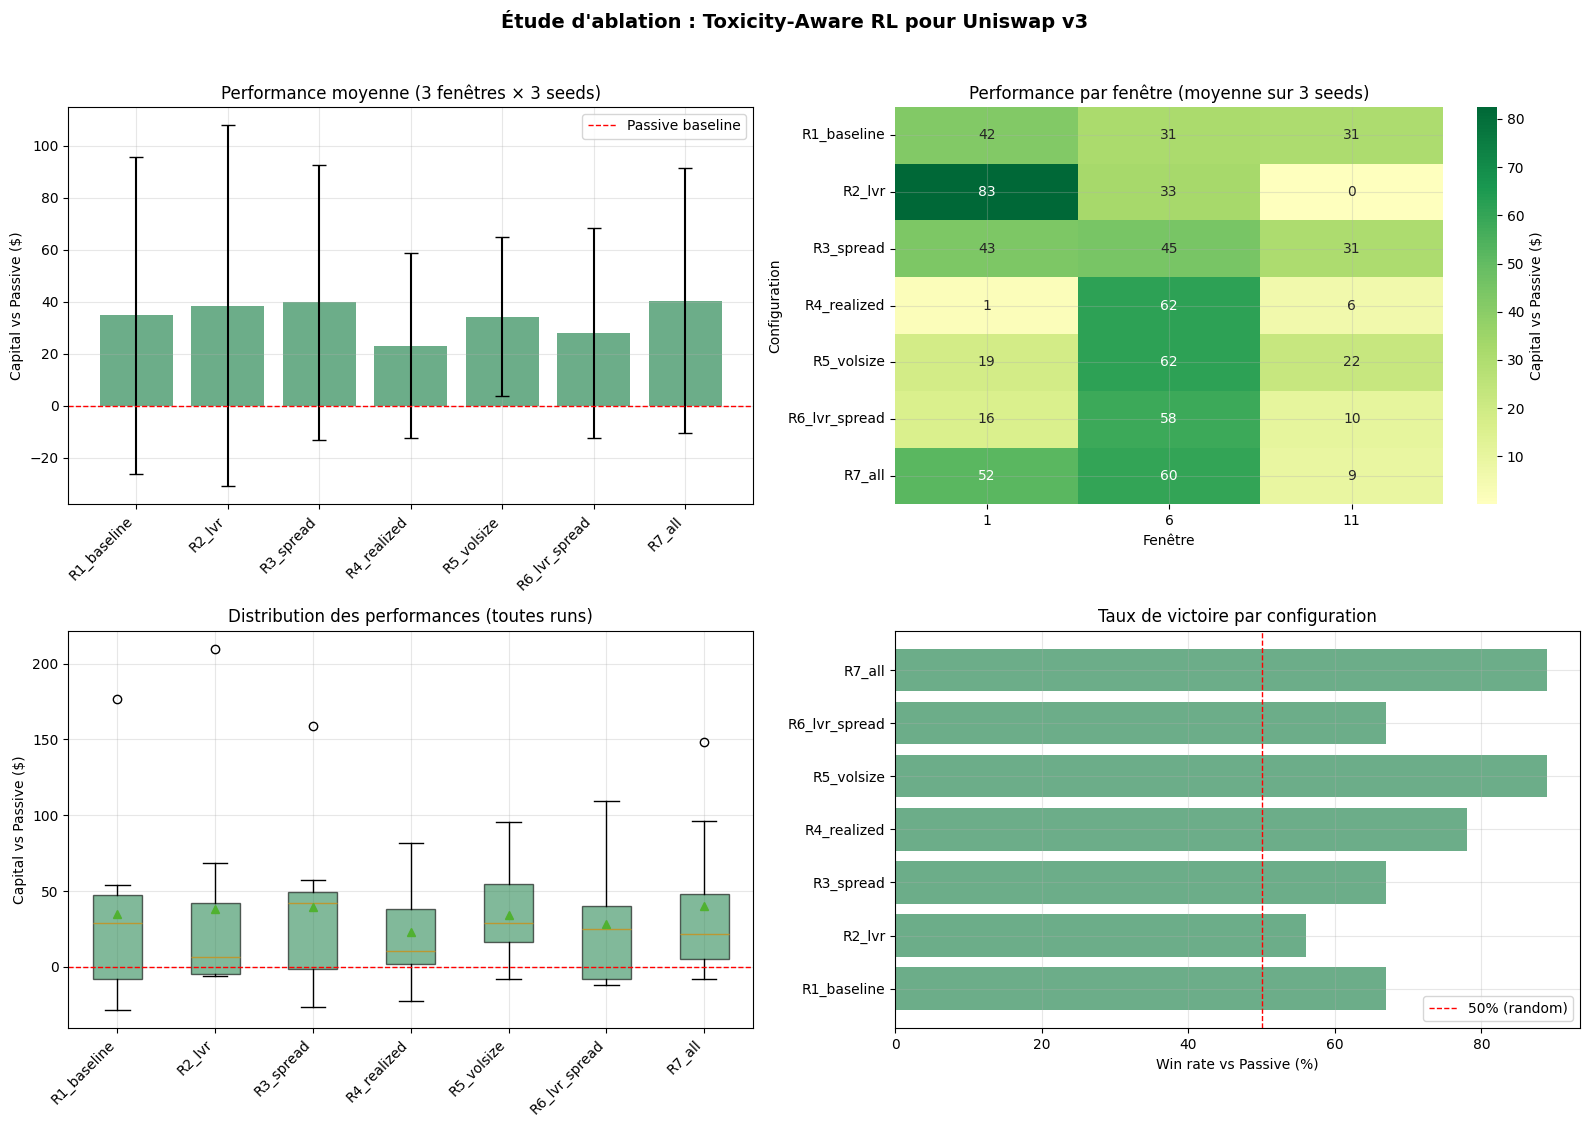


✅ Figure sauvegardée : /kaggle/working/results/phase2_summary.png


In [32]:
# 7. Visualisation des résultats Phase 2
if results_path.exists():
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    
    # ============================================================
    # Plot 1 : Capital moyen ± std par config (bar chart)
    # ============================================================
    summary_for_plot = summary.dropna()
    x = range(len(summary_for_plot))
    colors = ["steelblue" if v < 0 else "seagreen" 
              for v in summary_for_plot["vs_passive_mean"]]
    
    axes[0, 0].bar(x, summary_for_plot["vs_passive_mean"], 
                   yerr=summary_for_plot["vs_passive_std"],
                   color=colors, alpha=0.7, capsize=5)
    axes[0, 0].axhline(0, color="red", ls="--", lw=1, label="Passive baseline")
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(summary_for_plot.index, rotation=45, ha="right")
    axes[0, 0].set_ylabel("Capital vs Passive ($)")
    axes[0, 0].set_title("Performance moyenne (3 fenêtres × 3 seeds)")
    axes[0, 0].legend()
    axes[0, 0].grid(axis="y", alpha=0.3)
    
    # ============================================================
    # Plot 2 : Heatmap par fenêtre (mean over seeds)
    # ============================================================
    pivot_w = results_df.groupby(["config", "window"])["vs_passive"].mean().unstack()
    pivot_w = pivot_w.reindex([c["id"] for c in CONFIGS])
    sns.heatmap(pivot_w, annot=True, fmt=".0f", cmap="RdYlGn", center=0,
                ax=axes[0, 1], cbar_kws={"label": "Capital vs Passive ($)"})
    axes[0, 1].set_title("Performance par fenêtre (moyenne sur 3 seeds)")
    axes[0, 1].set_xlabel("Fenêtre")
    axes[0, 1].set_ylabel("Configuration")
    
    # ============================================================
    # Plot 3 : Distribution des résultats (boxplot par config)
    # ============================================================
    config_order = [c["id"] for c in CONFIGS]
    box_data = [results_df[results_df["config"] == cfg]["vs_passive"].values 
                for cfg in config_order]
    bp = axes[1, 0].boxplot(box_data, labels=config_order, patch_artist=True, showmeans=True)
    for patch, cfg in zip(bp["boxes"], config_order):
        mean_val = results_df[results_df["config"] == cfg]["vs_passive"].mean()
        patch.set_facecolor("seagreen" if mean_val > 0 else "steelblue")
        patch.set_alpha(0.6)
    axes[1, 0].axhline(0, color="red", ls="--", lw=1)
    axes[1, 0].set_xticklabels(config_order, rotation=45, ha="right")
    axes[1, 0].set_ylabel("Capital vs Passive ($)")
    axes[1, 0].set_title("Distribution des performances (toutes runs)")
    axes[1, 0].grid(axis="y", alpha=0.3)
    
    # ============================================================
    # Plot 4 : Win rate par config
    # ============================================================
    win_rates = summary_for_plot["win_rate"] * 100
    colors_win = ["seagreen" if wr >= 50 else "steelblue" for wr in win_rates]
    axes[1, 1].barh(range(len(win_rates)), win_rates, color=colors_win, alpha=0.7)
    axes[1, 1].axvline(50, color="red", ls="--", lw=1, label="50% (random)")
    axes[1, 1].set_yticks(range(len(win_rates)))
    axes[1, 1].set_yticklabels(summary_for_plot.index)
    axes[1, 1].set_xlabel("Win rate vs Passive (%)")
    axes[1, 1].set_title("Taux de victoire par configuration")
    axes[1, 1].legend()
    axes[1, 1].grid(axis="x", alpha=0.3)
    
    plt.suptitle("Étude d'ablation : Toxicity-Aware RL pour Uniswap v3", 
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "phase2_summary.png", dpi=120, bbox_inches="tight")
    plt.show()
    
    print(f"\n✅ Figure sauvegardée : {RESULTS_DIR / 'phase2_summary.png'}")

## ✅ Étape D terminée

**Résultats sauvegardés dans `/kaggle/working/results/` :**
- `phase2_results_final.csv` — tous les résultats détaillés
- `phase2_summary.png` — graphique récap pour le paper
- `models/` — 21 modèles PPO entraînés (1 par run)

**Prochaines étapes :**
1. **Si Phase 2 OK** → on rédige le paper avec ces résultats
2. **Si Phase 2 KO** (aucune config bat passive) → on ajuste hyperparams ou reward shaping